# data prepare

In [101]:
import pandas as pd
import json
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from tqdm import tqdm
import gc


csv_path=r"C:\Users\Administrator\Desktop\Chess\data\processed\hpc_results\HPC_RESULTS.csv"
df=pd.read_csv(csv_path)

In [102]:
df.head()

,row_idx,UID,White,Black,White CP Loss,White Accuracy,Black CP Loss,Black Accuracy,Stage Analysis,Evaluation,...,Black Inaccuracies,Complexity E1,Complexity E2,Complexity E3,Complexity E4,Complexity E5,Complexity P,Complexity S,White Complexity Sum,Black Complexity Sum
0,0,34,Dennis Wagner,Petar Ratkovic,21.9,95.8,52.1,90.7,{},"0.33,0.36,0.30,0.44,0.32,0.39,0.40,0.39,0.32,0...",...,1,"36,33,36,30,44,32,39,40,39,32,50,42,66,56,70,5...","34,34,33,63,35,37,38,47,23,46,40,55,58,57,55,6...","31,34,27,66,26,67,36,60,17,49,29,55,48,65,29,7...","25,42,25,78,21,71,34,67,12,52,26,57,35,74,28,8...","16,48,20,79,21,72,25,83,11,53,18,62,28,90,27,9...","0.550,0.525,0.574,0.964,0.711,0.622,0.525,0.66...","0.863,0.930,0.800,0.052,0.492,0.684,0.930,0.58...",10.503580,10.475061
1,1,35,AradNazari,Andre Bold,23.5,96.5,58.1,91.2,{},"0.28,0.37,0.39,0.36,0.18,0.14,0.36,0.42,0.40,0...",...,2,"31,28,37,39,36,18,14,36,42,40,35,37,41,35,35,3...","30,30,33,40,35,93,-22,36,2,41,19,76,29,262,-46...","28,31,27,41,32,141,-55,39,-12,42,1,80,20,276,-...","23,31,27,43,28,141,-67,47,-22,52,-13,92,5,345,...","12,50,26,45,16,180,-85,48,-51,52,-19,119,-3,38...","0.525,0.550,0.599,0.525,0.525,0.999,0.973,0.50...","0.930,0.863,0.740,0.930,0.930,0.001,0.039,1.00...",8.113573,13.235301
2,2,36,Mitra Asgharzadeh,Shant Sargsyan,36.5,89.7,17.4,94.4,{},"0.29,0.59,0.33,0.43,0.11,0.17,0.06,0.19,0.05,0...",...,2,"25,29,59,33,43,11,17,6,19,5,9,-1,17,11,11,13,2...","21,31,44,44,29,29,10,9,16,17,0,5,11,13,7,13,19...","20,31,40,55,14,36,8,12,3,17,-4,11,11,14,3,14,1...","13,32,33,60,9,41,8,23,0,19,-7,12,8,19,3,16,16,...","10,54,22,64,9,46,8,29,0,21,-18,17,8,22,3,18,10...","0.599,0.550,0.818,0.750,0.802,0.858,0.668,0.57...","0.740,0.863,0.291,0.415,0.318,0.221,0.582,0.80...",12.108152,11.347072
3,3,37,Bartosz Przybylski,Joseph Ryan,33.2,92.4,71.0,87.5,{},"0.22,0.39,0.36,0.51,0.42,0.48,0.37,0.44,0.28,0...",...,1,"29,22,39,36,51,42,48,37,44,28,26,37,66,66,64,7...","25,23,33,37,43,53,26,37,39,28,21,58,-8,66,49,9...","21,27,21,41,33,59,22,38,26,29,0,60,-23,69,49,1...","13,28,19,47,32,67,15,38,0,31,-22,80,-41,104,47...","7,48,10,51,25,68,1,39,-7,35,-25,87,-57,111,40,...","0.599,0.525,0.646,0.525,0.690,0.750,0.900,0.50...","0.740,0.930,0.631,0.930,0.535,0.415,0.152,1.00...",6.912318,9.204628
4,4,38,Samvel Ter-Sahakyan,Denis Garrido,26.9,92.7,38.5,89.6,{},"0.31,0.28,0.28,0.36,0.30,0.39,0.39,0.39,0.31,0...",...,4,"35,31,28,28,36,30,39,39,39,31,35,31,30,15,27,2...","32,32,27,30,29,33,26,210,35,33,20,32,25,114,23...","20,32,15,35,25,35,23,212,30,36,17,35,23,398,22...","17,33,12,50,22,39,16,215,23,37,16,35,16,519,15...","17,43,6,60,16,40,15,229,22,43,13,37,12,521,13,...","0.574,0.525,0.525,0.550,0.668,0.574,0.786,1.00...","0.800,0.930,0.930,0.863,0.582,0.800,0.348,0.00...",14.144930,18.045869


In [103]:
df.columns

Index(['row_idx', 'UID', 'White', 'Black', 'White CP Loss', 'White Accuracy',
       'Black CP Loss', 'Black Accuracy', 'Stage Analysis', 'Evaluation',
       'ComplexityE', 'Judgments', 'White Blunders', 'White Mistakes',
       'White Inaccuracies', 'Black Blunders', 'Black Mistakes',
       'Black Inaccuracies', 'Complexity E1', 'Complexity E2', 'Complexity E3',
       'Complexity E4', 'Complexity E5', 'Complexity P', 'Complexity S',
       'White Complexity Sum', 'Black Complexity Sum'],
      dtype='object')

In [104]:
df.drop(columns=['row_idx', 'White CP Loss', 'White Accuracy', 'Black CP Loss', 'Black Accuracy', 'Stage Analysis'],inplace=True)
df.columns

Index(['UID', 'White', 'Black', 'Evaluation', 'ComplexityE', 'Judgments',
       'White Blunders', 'White Mistakes', 'White Inaccuracies',
       'Black Blunders', 'Black Mistakes', 'Black Inaccuracies',
       'Complexity E1', 'Complexity E2', 'Complexity E3', 'Complexity E4',
       'Complexity E5', 'Complexity P', 'Complexity S', 'White Complexity Sum',
       'Black Complexity Sum'],
      dtype='object')

In [105]:
# 适用于大数据集版本的
def parse_chess_data_safe(df):
    num_cols = ['ComplexityE', 'Complexity E1', 'Complexity E2','Complexity E3', 'Complexity E4', 'Complexity E5', 'Complexity P', 'Complexity S']

    for col in num_cols:
        s = df[col].astype(str).str.split(',')  # 拆分字符串
        # 用 NaN 替代空字符串或无法转换为 float 的值
        df[col] = s.apply(lambda lst: np.array([float(i) if i.strip() != '' else np.nan for i in lst], dtype=np.float32)
                          if isinstance(lst, list) else np.array([np.nan], dtype=np.float32))

    # Judgments 列只拆成列表，不转 float
    df['Judgments'] = df['Judgments'].astype(str).str.split(',')

    return df
def to_list_safe(x):
    if isinstance(x, list):
        return x
    elif isinstance(x, (np.ndarray, pd.Series)):
        return x.tolist()
    elif isinstance(x, str):
        # 空字符串或者单个元素用 split
        return x.split(',') if x.strip() != '' else []
    else:
        return []
df.columns = [c.replace(' ', '_') for c in df.columns]

In [ ]:
# 小数据集可用，大的不行
def parse_chess_data(df):
    list_cols = ['Judgments', 'ComplexityE', 'Complexity E1', 'Complexity E2', 'Complexity P', 'Complexity S']
    
    for col in list_cols:
        df[col] = df[col].apply(lambda x: [float(i) for i in x.split(',')] if isinstance(x, str) and col != 'Judgments' else x)
        
    df['Judgments'] = df['Judgments'].apply(lambda x: x.split(',') if isinstance(x, str) else x)
    return df
df=parse_chess_data(df)
df.head()

In [106]:
df.columns

Index(['UID', 'White', 'Black', 'Evaluation', 'ComplexityE', 'Judgments',
       'White_Blunders', 'White_Mistakes', 'White_Inaccuracies',
       'Black_Blunders', 'Black_Mistakes', 'Black_Inaccuracies',
       'Complexity_E1', 'Complexity_E2', 'Complexity_E3', 'Complexity_E4',
       'Complexity_E5', 'Complexity_P', 'Complexity_S', 'White_Complexity_Sum',
       'Black_Complexity_Sum'],
      dtype='object')

In [107]:
def explode_chess_data(row):
    game_id = row['UID']
    white = row['White']
    black = row['Black']
    
    complexities = to_list_safe(row['Complexity_S'])
    Es = to_list_safe(row['ComplexityE'])
    E1s = to_list_safe(row['Complexity_E1'])
    E2s = to_list_safe(row['Complexity_E2'])
    E3s = to_list_safe(row['Complexity_E3'])
    E4s = to_list_safe(row['Complexity_E4'])
    E5s = to_list_safe(row['Complexity_E5'])
    Ps = to_list_safe(row['Complexity_P'])
    Ss = to_list_safe(row['Complexity_S'])
    judgments = to_list_safe(row['Judgments'])
    if not isinstance(complexities, list):
        complexities = [] 
    if not isinstance(Es, list):
        Es = []
    if not isinstance(E1s, list):
        E1s = []
    if not isinstance(E2s, list):
        E2s = []   
    if not isinstance(Ps, list):
        Ps = [] 
    if not isinstance(judgments, list):
        judgments = []

    length = max(len(complexities), len(Es), len(E1s), len(E2s), len(Ps), len(judgments))
    exploded_data = []
    
    for i in range(length):
        # 偶数步是白方，奇数步是黑方 (0, 1, 2, 3...)
        is_white_move = (i % 2 == 0)
        player_name = white if is_white_move else black
        color_str = 'White' if is_white_move else 'Black'

        # 对空列表或越界索引用 np.nan / 'Unknown' 占位
        s_val = complexities[i] if i < len(complexities) else np.nan
        e_val = Es[i] if i < len(Es) else np.nan
        e1_val = E1s[i] if i < len(E1s) else np.nan
        e2_val = E2s[i] if i < len(E2s) else np.nan
        e3_val = E1s[i] if i < len(E3s) else np.nan
        e4_val = E2s[i] if i < len(E4s) else np.nan
        e5_val = E1s[i] if i < len(E5s) else np.nan
        p_val = Ps[i] if i < len(Ps) else np.nan
        judgment_str = judgments[i] if i < len(judgments) else 'Unknown'

        is_error = 1 if judgment_str in ['Blunder', 'Mistake'] else 0
        is_blunder = 1 if judgment_str == 'Blunder' else 0

        exploded_data.append({
            'uid': game_id,
            'Move_Idx': i + 1,
            'Player': player_name,
            'Color': color_str,
            'S': s_val,
            'E': e_val,
            'E1': e1_val,
            'E2': e2_val,
            'E3': e3_val,
            'E4': e4_val,
            'E5': e5_val,
            'P': p_val,
            'Judgment_Raw': judgment_str,
            'Is_Error': is_error,
            'Is_Blunder': is_blunder
        })
    
    return exploded_data

chunks = []
buffer = []

BUFFER_SIZE = 200000  # moves 数量，不是 games

for row in tqdm(df.itertuples(index=False), total=len(df)):
    moves = explode_chess_data(row._asdict())
    buffer.extend(moves)

    if len(buffer) >= BUFFER_SIZE:
        chunks.append(pd.DataFrame(buffer))
        buffer = []

# 最后剩余部分
if buffer:
    chunks.append(pd.DataFrame(buffer))

df_moves = pd.concat(chunks, ignore_index=True)

print(df_moves.shape)

100%|██████████| 712321/712321 [01:41<00:00, 7006.51it/s]


(62435563, 15)


In [108]:
print(df_moves.columns.tolist())
print(df_moves.head())

['uid', 'Move_Idx', 'Player', 'Color', 'S', 'E', 'E1', 'E2', 'E3', 'E4', 'E5', 'P', 'Judgment_Raw', 'Is_Error', 'Is_Blunder']
   uid  Move_Idx          Player  Color      S   E  E1  E2  E3  E4  E5      P  \
0   34         1   Dennis Wagner  White  0.863  33  36  34  36  34  36  0.550   
1   34         2  Petar Ratkovic  Black  0.930  36  33  34  33  34  33  0.525   
2   34         3   Dennis Wagner  White  0.800  30  36  33  36  33  36  0.574   
3   34         4  Petar Ratkovic  Black  0.052  44  30  63  30  63  30  0.964   
4   34         5   Dennis Wagner  White  0.492  32  44  35  44  35  44  0.711   

  Judgment_Raw  Is_Error  Is_Blunder  
0            -         0           0  
1            -         0           0  
2            -         0           0  
3            -         0           0  
4            -         0           0  


# 存成别的格式，减少开销，减少重新读取和格式转换

In [29]:
df_moves.to_parquet('moves_optimized.parquet', engine='pyarrow', compression='snappy')
# df_moves = pd.read_parquet('moves_optimized.parquet')
# print(df_moves.dtypes)
# 按列读取：
# df_sub = pd.read_parquet('moves_optimized.parquet', columns=['Player', 'Is_Error', 'Is_Blunder', 'Color'])

df_moves.to_parquet("moves.parquet")
del df_moves
gc.collect()
df_moves = pd.read_parquet("moves.parquet")

缩小df_moves的大小

In [22]:
# 查看每一列占用的真实内存（包括字符串对象的开销）
print(df_moves.memory_usage(deep=True) / 1024**2) # 单位：MB
print("-" * 30)
print(df_moves.dtypes)

Index              0.000126
uid              476.345543
Move_Idx         476.345543
Player          3941.539489
Color           3215.332415
S               3217.892221
E               3078.918706
E1              3078.209762
E2              3078.355097
P               3215.332415
Judgment_Raw    3038.986904
Is_Error         476.345543
Is_Blunder       476.345543
dtype: float64
------------------------------
uid              int64
Move_Idx         int64
Player          object
Color           object
S               object
E               object
E1              object
E2              object
P               object
Judgment_Raw    object
Is_Error         int64
Is_Blunder       int64
dtype: object


In [109]:
# 数值列从object转化为float32
num_cols = ['S', 'E', 'E1', 'E2', 'E3', 'E4', 'E5', 'P']
for col in num_cols:
    df_moves[col] = pd.to_numeric(df_moves[col], errors='coerce').astype(np.float32)
# 分类列转换
cat_cols = ['Player', 'Color', 'Judgment_Raw']
for col in cat_cols:
    df_moves[col] = df_moves[col].astype('category')
# 数列空间优化
df_moves['uid'] = df_moves['uid'].astype(np.int32)
df_moves['Move_Idx'] = df_moves['Move_Idx'].astype(np.int16)
df_moves['Is_Error'] = df_moves['Is_Error'].astype(np.uint8)
df_moves['Is_Blunder'] = df_moves['Is_Blunder'].astype(np.uint8)
gc.collect()

0

In [110]:
print(df_moves.memory_usage(deep=True).sum() / 1024**3, "GB")

2.5592077393084764 GB


# 节省内存注意

禁用 .apply() 和手动 for 循环    
（向量化）：df['new'] = df['S'] * 10 （利用 NumPy 底层加速，快几百倍）    
    
df = df.reset_index() 或 df = df.sort_values()）会默认创建一个数据的完整副本。
如果你的内存只有 16GB，当你拥有一个 2.5GB 的 DF 时，一旦产生 2-3 个副本，内存就会瞬间飙升回 10GB 左右。
技巧：不用的中间变量及时 del 掉，并运行 gc.collect()

groupby 的高效聚合    
如果你想算“每个玩家的平均错误率”或“不同复杂度的胜率”，请直接使用聚合函数：    
计算每个玩家的平均错误数（Is_Error 是 uint8，计算速度极快）    
player_stats = df_moves.groupby('Player')['Is_Error'].mean()

### perspective fix   (important!)

In [111]:
df_moves.loc[df_moves['Color']=='Black', ['E1', 'E2']] *= -1
df_moves.head()

,uid,Move_Idx,Player,Color,S,E,E1,E2,E3,E4,E5,P,Judgment_Raw,Is_Error,Is_Blunder
0,34,1,Dennis Wagner,White,0.863,33.0,36.0,34.0,36.0,34.0,36.0,0.550,-,0,0
1,34,2,Petar Ratkovic,Black,0.930,36.0,-33.0,-34.0,33.0,34.0,33.0,0.525,-,0,0
2,34,3,Dennis Wagner,White,0.800,30.0,36.0,33.0,36.0,33.0,36.0,0.574,-,0,0
3,34,4,Petar Ratkovic,Black,0.052,44.0,-30.0,-63.0,30.0,63.0,30.0,0.964,-,0,0
4,34,5,Dennis Wagner,White,0.492,32.0,44.0,35.0,44.0,35.0,44.0,0.711,-,0,0


for black :   
E1 < E2   
but E sometimes less than E2 even less than E1   
i asked it says its normal because the enignee's limitation      

https://chess.stackexchange.com/questions/46296/how-is-it-possible-for-the-eval-to-reduce-after-playing-the-best-move?utm_source=chatgpt.com   
The horizon effect. The engine can only see so far. When you make a move, it can now see further and find the draw that it missed before when it still needed to look at all the alternatives too.
地平线效应。引擎只能看得很远。当你走牌时，它现在能看得更远，找到之前错过的抽签，而当时还需要查看所有备选方案。

Especially when the line involves "probably wrong" moves, like sacrifices that don't bring immediate returns, they may get disregarded (pruned) quickly while they're further out, but may be considered seriously if they're 1 move closer to the current position.
尤其是当这条线涉及“可能错误”的走法，比如牺牲不会立即带来回报时，他们可能在更远时被迅速忽视（修剪），但如果他们离当前位置更近一步，可能会被认真考虑。

In [112]:
df_moves['Δ']= abs(df_moves['E1']-df_moves['E2'])
#white E1-E   black E-E1
df_moves['Δ_i']= np.where(
    df_moves['Color']=='White',
    df_moves['E1']-df_moves['E'],
    df_moves['E']-df_moves['E1']
)
df_moves.head()

,uid,Move_Idx,Player,Color,S,E,E1,E2,E3,E4,E5,P,Judgment_Raw,Is_Error,Is_Blunder,Δ,Δ_i
0,34,1,Dennis Wagner,White,0.863,33.0,36.0,34.0,36.0,34.0,36.0,0.550,-,0,0,2.0,3.0
1,34,2,Petar Ratkovic,Black,0.930,36.0,-33.0,-34.0,33.0,34.0,33.0,0.525,-,0,0,1.0,69.0
2,34,3,Dennis Wagner,White,0.800,30.0,36.0,33.0,36.0,33.0,36.0,0.574,-,0,0,3.0,6.0
3,34,4,Petar Ratkovic,Black,0.052,44.0,-30.0,-63.0,30.0,63.0,30.0,0.964,-,0,0,33.0,74.0
4,34,5,Dennis Wagner,White,0.492,32.0,44.0,35.0,44.0,35.0,44.0,0.711,-,0,0,9.0,12.0


In [113]:
# 查看 Δ_i 的分布
df_moves['Δ_i'] = pd.to_numeric(df_moves['Δ_i'], errors='coerce').astype(np.float32)
print(df_moves['Δ_i'].describe())

count    6.243556e+07
mean     9.322150e+01
std      2.671366e+03
min     -1.999800e+04
25%     -2.000000e+00
50%      1.100000e+01
75%      7.700000e+01
max      1.999800e+04
Name: Δ_i, dtype: float64


In [114]:
tolerance_cp= 10
df_moves['Is_Optimal'] = np.where(df_moves['Δ_i'] <= tolerance_cp, 1, 0)
df_moves.head()

,uid,Move_Idx,Player,Color,S,E,E1,E2,E3,E4,E5,P,Judgment_Raw,Is_Error,Is_Blunder,Δ,Δ_i,Is_Optimal
0,34,1,Dennis Wagner,White,0.863,33.0,36.0,34.0,36.0,34.0,36.0,0.550,-,0,0,2.0,3.0,1
1,34,2,Petar Ratkovic,Black,0.930,36.0,-33.0,-34.0,33.0,34.0,33.0,0.525,-,0,0,1.0,69.0,0
2,34,3,Dennis Wagner,White,0.800,30.0,36.0,33.0,36.0,33.0,36.0,0.574,-,0,0,3.0,6.0,1
3,34,4,Petar Ratkovic,Black,0.052,44.0,-30.0,-63.0,30.0,63.0,30.0,0.964,-,0,0,33.0,74.0,0
4,34,5,Dennis Wagner,White,0.492,32.0,44.0,35.0,44.0,35.0,44.0,0.711,-,0,0,9.0,12.0,0


In [115]:
df_moves['Is_Optimal'].dtype
df_moves['Is_Optimal'] = df_moves['Is_Optimal'].astype(np.int32)

In [116]:
# fit_df = df_moves[(df_moves['Δ'] >= 0.1) & (df_moves['Δ'] <= 1000)].copy()
mask = (df_moves['Δ']>=0.1) & (df_moves['Δ'] <=1000)
needed_columns = ['Δ', 'S', 'Is_Optimal']
fit_df = df_moves.loc[mask, needed_columns].copy()
print(f"参与拟合的数据量: {len(fit_df)}")
print(f"子集内存占用: {fit_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"整体最优率 (Base Accuracy): {fit_df['Is_Optimal'].mean():.2%}")

参与拟合的数据量: 54902434
子集内存占用: 1047.18 MB
整体最优率 (Base Accuracy): 47.30%


In [117]:
#加上elo相关信息
# 内存管理
elo_dtypes = {'uid': np.int32, 'player': 'category', 'My_Elo': np.float32}
elo_info = pd.read_csv(r"C:\Users\Administrator\Desktop\Chess\ELO\temp.csv",usecols=['uid','player', 'My_Elo'], dtype=elo_dtypes)
elo_info = elo_info.drop_duplicates(subset=['uid', 'player'])
elo_info = elo_info.rename(columns={'My_Elo': 'ELO', 'player': 'Player'})
elo_info.head()

,uid,Player,ELO
0,540927,107degrees,2114.0
1,541102,107degrees,2111.0
2,541585,107degrees,2124.0
3,541718,107degrees,2132.0
4,541348,107degrees,2116.0


In [118]:
df_moves = df_moves.merge(
    elo_info,
    left_on=['uid', 'Player'],   # df_moves 中的列
    right_on=['uid', 'Player'],      # elo_info 中的列
    how='left'
)
del elo_info
gc.collect()
df_moves.head()

,uid,Move_Idx,Player,Color,S,E,E1,E2,E3,E4,E5,P,Judgment_Raw,Is_Error,Is_Blunder,Δ,Δ_i,Is_Optimal,ELO
0,34,1,Dennis Wagner,White,0.863,33.0,36.0,34.0,36.0,34.0,36.0,0.550,-,0,0,2.0,3.0,1,2802.0
1,34,2,Petar Ratkovic,Black,0.930,36.0,-33.0,-34.0,33.0,34.0,33.0,0.525,-,0,0,1.0,69.0,0,2463.0
2,34,3,Dennis Wagner,White,0.800,30.0,36.0,33.0,36.0,33.0,36.0,0.574,-,0,0,3.0,6.0,1,2802.0
3,34,4,Petar Ratkovic,Black,0.052,44.0,-30.0,-63.0,30.0,63.0,30.0,0.964,-,0,0,33.0,74.0,0,2463.0
4,34,5,Dennis Wagner,White,0.492,32.0,44.0,35.0,44.0,35.0,44.0,0.711,-,0,0,9.0,12.0,0,2802.0


In [119]:
df_moves['ELO'].describe()
bins = [-np.inf, 2000, 2200, 2400, 2600, 2800, 3000, np.inf]
labels = ['<2000', '2000-2200', '2200-2400', '2400-2600', '2600-2800', '2800-3000', '>=3000']

# pd.cut 分桶 比.apply要快很多
df_moves['ELO_Group'] = pd.cut(
    df_moves['ELO'], 
    bins=bins, 
    labels=labels, 
    right=False  # 左闭右开 [2400, 2800)
)
print(df_moves['ELO_Group'].value_counts())

ELO_Group
2400-2600    20820973
2600-2800    14749320
2200-2400    11491349
2800-3000     8500866
2000-2200     3146274
>=3000        3042697
<2000          684084
Name: count, dtype: int64


In [120]:
force_moves_csv=r'C:\Users\Administrator\Desktop\Chess\data\input\forced_moves_per_game.csv'
force_moves_df=pd.read_csv(force_moves_csv, usecols=['Game_ID', 'Forced_Move_Idx_List'])
def fast_parse(x):
    if pd.isna(x) or x == "" or x == "[]":
        return []
    try:
        # 是 [1, 2] 这种标准 JSON 格式
        return json.loads(x)
    except:
        # 是 '1, 2' 这种
        try:
            return [int(i) for i in str(x).replace('[','').replace(']','').split(',') if i.strip()]
        except:
            return []
force_moves_df['Forced_Move_Idx_List'] = force_moves_df['Forced_Move_Idx_List'].apply(fast_parse)

# 用explode 将force_moves_df拆成很多行
df_forced_expanded = force_moves_df.explode('Forced_Move_Idx_List')
df_forced_expanded = df_forced_expanded.dropna(subset=['Forced_Move_Idx_List'])
df_forced_expanded = df_forced_expanded.rename(columns={'Game_ID': 'uid', 'Forced_Move_Idx_List': 'Move_Idx'})
df_forced_expanded['uid'] = df_forced_expanded['uid'].astype(np.int32)
df_forced_expanded['Move_Idx'] = df_forced_expanded['Move_Idx'].astype(np.int16)
df_forced_expanded['Is_Forced'] = 1
df_forced_expanded['Is_Forced'] = df_forced_expanded['Is_Forced'].astype(np.uint8)
df_forced_expanded = df_forced_expanded.drop_duplicates(subset=['uid', 'Move_Idx'])

del force_moves_df
gc.collect()

0

In [121]:
# 1. 检查并删除原有的 Is_Forced 列（防止重复合并产生 _x, _y 后缀）
if 'Is_Forced' in df_moves.columns:
    df_moves.drop(columns=['Is_Forced'], inplace=True)
df_moves = df_moves.merge(
    df_forced_expanded, 
    on=['uid', 'Move_Idx'], 
    how='left'
)
# 填充空值：没匹配上的不是 Forced
df_moves['Is_Forced'] = df_moves['Is_Forced'].fillna(0).astype(np.uint8)

del df_forced_expanded
gc.collect()

print("全部处理完成")
print(df_moves['Is_Forced'].value_counts())

MemoryError: Unable to allocate 2.56 GiB for an array with shape (11, 62435563) and data type float32

In [ ]:
df_moves.columns

Index(['uid', 'Move_Idx', 'Player', 'Color', 'S', 'E', 'E1', 'E2', 'E3', 'E4',
       'E5', 'P', 'Judgment_Raw', 'Is_Error', 'Is_Blunder', 'Δ', 'Δ_i',
       'Is_Optimal', 'ELO', 'ELO_Group', 'Is_Forced'],
      dtype='object')

In [67]:
df_moves.to_parquet('moves_final_forced.parquet')

In [82]:
df_moves.head()

,uid,Move_Idx,Player,Color,S,E,E1,E2,E3,E4,...,P,Judgment_Raw,Is_Error,Is_Blunder,Δ,Δ_i,Is_Optimal,ELO,ELO_Group,Is_Forced
0,34,1,Dennis Wagner,White,0.863,33.0,36.0,34.0,36.0,34.0,...,0.550,-,0,0,2.0,3.0,1,2802.0,2800-3000,0
1,34,2,Petar Ratkovic,Black,0.930,36.0,-33.0,-34.0,33.0,34.0,...,0.525,-,0,0,1.0,69.0,0,2463.0,2400-2600,0
2,34,3,Dennis Wagner,White,0.800,30.0,36.0,33.0,36.0,33.0,...,0.574,-,0,0,3.0,6.0,1,2802.0,2800-3000,0
3,34,4,Petar Ratkovic,Black,0.052,44.0,-30.0,-63.0,30.0,63.0,...,0.964,-,0,0,33.0,74.0,0,2463.0,2400-2600,0
4,34,5,Dennis Wagner,White,0.492,32.0,44.0,35.0,44.0,35.0,...,0.711,-,0,0,9.0,12.0,0,2802.0,2800-3000,0


聚合全表加快速度

In [ ]:
# 筛选： 非强迫走子 delta在绘图范围内
mask = (df_moves['Is_Forced'] == 0) & (df_moves['Δ'] > 0) & (df_moves['Δ'] <= 3000)
temp_df = df_moves.loc[mask, ['ELO_Group', 'Δ', 'Is_Optimal']]
agg_stats = temp_df.groupby(['ELO_Group', 'Δ'], observed=True)['Is_Optimal'].agg(['mean', 'count']).reset_index()
agg_stats.rename(columns={'mean': 'P_Optimal'}, inplace=True)
del temp_df
gc.collect()

4786

# 在调整成10k的时候最末尾还有，可以后面单独分析一下

In [122]:
# 筛选： 非强迫走子 delta在绘图范围内
mask = (df_moves['Is_Forced'] == 0) & (df_moves['Δ'] > 0) & (df_moves['Δ'] <= 3000)
# mask = (df_moves['Is_Forced'] == 0) & (df_moves['Δ'] > 0) & (df_moves['Δ'] <= 10000)

temp_df = df_moves.loc[mask, ['ELO_Group', 'Δ', 'Is_Optimal']]
agg_stats_3000 = temp_df.groupby(['ELO_Group', 'Δ'], observed=True)['Is_Optimal'].agg(['mean', 'count']).reset_index()
agg_stats_3000.rename(columns={'mean': 'P_Optimal'}, inplace=True)
del temp_df
gc.collect()

def plot_wide_view(stats):
    plt.figure(figsize=(12, 6))
    # ['<2000', '2000-2200', '2200-2400', '2400-2600', '2600-2800', '2800-3000', '>=3000']
    colors = {'<2000': 'blue', '2000-2200':'purple', '2200-2400':'green', '2400-2600':'orange', '2600-2800':'yellow', '2800-3000':'pink', '>=3000':'red'}
    
    for g in ['<2000', '2000-2200', '2200-2400', '2400-2600', '2600-2800', '2800-3000', '>=3000']:
        # 提高样本门槛，保证长尾数据可靠
        data = stats[(stats['ELO_Group'] == g) & (stats['count'] >= 100)]
        plt.plot(data['Δ'], data['P_Optimal'], label=g, color=colors[g], alpha=0.8)
    
    plt.axhline(y=1.0, color='black', linestyle=':', alpha=0.5, label='Theoretical Max (1.0)')
    plt.title("P(Optimal) Wide View (0-3000 cp)")
    plt.xlabel("Delta (cp)")
    plt.ylabel("P(Optimal)")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

plot_wide_view(agg_stats_3000)

KeyError: 'Is_Forced'

验证聚合压缩策略是否能保证结果不发生变化

In [ ]:
# 选一个特定组和特定的 Delta 范围进行对比
test_group = 'Mid (2400-2799)'
test_delta = 50

# 方式 A：老老实实从 6200 万行原表算
raw_mean = df_moves[(df_moves['ELO_Group'] == test_group) & (df_moves['Δ'] == test_delta)]['Is_Optimal'].mean()

# 方式 B：从聚合后的几千行小表算
agg_mean = agg_stats[(agg_stats['ELO_Group'] == test_group) & (agg_stats['Δ'] == test_delta)]['P_Optimal'].iloc[0]

print(f"原表计算结果: {raw_mean}")
print(f"聚合计算结果: {agg_mean}")
print(f"两者是否完全相等: {np.isclose(raw_mean, agg_mean)}")

原表计算结果: 0.45098562911396767
聚合计算结果: 0.45098562911396767
两者是否完全相等: True


In [ ]:
# 原始数据中 Delta 的最大值
print(f"原始数据中 Δ 的最大值是: {df_moves['Δ'].max()}")

# 检查 1000 以上的数据量有多少
over_1000_count = (df_moves['Δ'] > 1000).sum()
print(f"Δ > 1000 的样本数: {over_1000_count} 行")

原始数据中 Δ 的最大值是: 19998.0
Δ > 1000 的样本数: 842556 行


<2400 组: A=0.645, 0.73A=0.471, Δ0≈170.8
2000-2200 组: A=0.669, 0.73A=0.488, Δ0≈185.6
2200-2400 组: A=0.697, 0.73A=0.509, Δ0≈144.7
2400-2600 组: A=0.720, 0.73A=0.525, Δ0≈129.0
2600-2800 组: A=0.742, 0.73A=0.542, Δ0≈113.2
2800-3000 组: A=0.766, 0.73A=0.559, Δ0≈85.4
>=3000 组: A=0.786, 0.73A=0.573, Δ0≈65.8


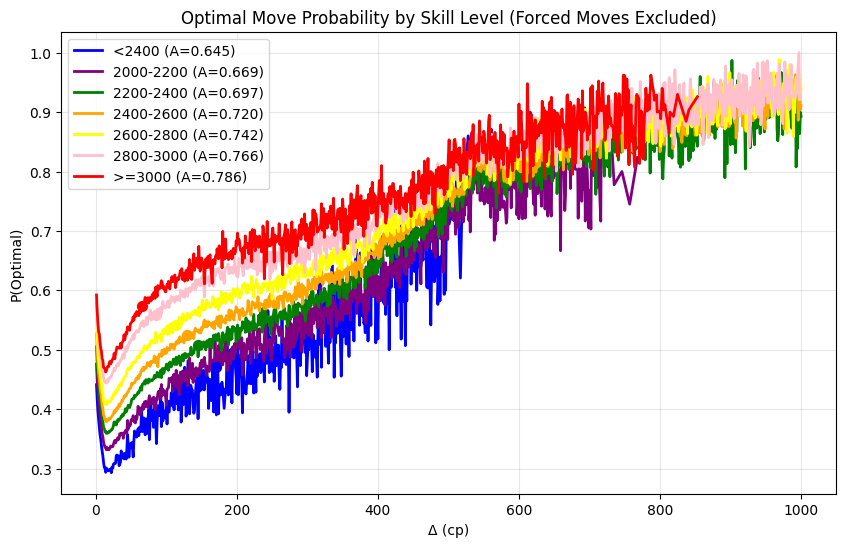

In [ ]:
def get_group_results(agg_stats, group_name, plot_max=3000, ceiling_start=1000):
    """
    plot_max: 绘图的最大 Delta，建议与计算 Ceiling 的范围一致
    ceiling_start: 从哪个 Delta 开始认为进入了“天花板”平台期
    """
    # 1. 获取曲线数据 (增加绘图范围到 plot_max，确保视觉一致性)
    curve_data = agg_stats[
        (agg_stats['ELO_Group'] == group_name) & 
        (agg_stats['Δ'] <= plot_max) & 
        (agg_stats['count'] >= 50)  # 样本量门槛可以根据实际情况微调
    ].sort_values('Δ').copy()
    
    # 2. 计算 Ceiling (建议起点往后挪，确保已经进入平台期)
    ceiling_data = agg_stats[
        (agg_stats['ELO_Group'] == group_name) & 
        (agg_stats['Δ'] >= ceiling_start) & 
        (agg_stats['Δ'] <= 1000)
    ]
    
    if ceiling_data.empty:
        A_empirical = curve_data['P_Optimal'].iloc[-1] # 兜底：取最后一点
    else:
        # 加权平均计算更准确
        A_empirical = (ceiling_data['P_Optimal'] * ceiling_data['count']).sum() / ceiling_data['count'].sum()
    
    return curve_data, A_empirical

# --- 调用部分 ---
groups = ['<2000', '2000-2200', '2200-2400', '2400-2600', '2600-2800', '2800-3000', '>=3000']
results = {}

for g in groups:
    # 统一将绘图和计算范围扩展到 1000，Ceiling 从 300 开始算
    curve, A = get_group_results(agg_stats, g, plot_max=1000, ceiling_start=300)
    results[g] = {'curve': curve, 'A': A}

def get_empirical_delta0_right(prob_df, target_prob):
    # 1. 安全检查：如果数据为空，直接返回 None
    if prob_df is None or prob_df.empty or len(prob_df) < 2:
        return None
        
    # 2. 找到 P_Optimal 最小点后的右半段
    try:
        idx_min = prob_df['P_Optimal'].idxmin()
        right_df = prob_df.loc[idx_min:].copy()
    except:
        return None

    # 3. 再次检查切片后是否有足够数据
    if len(right_df) < 2:
        return None
        
    # 4. 为了 np.interp 正常工作，xp (这里是 y) 必须是升序的
    # 我们对右半段按 P_Optimal 排序
    right_df = right_df.sort_values('P_Optimal')
    
    x = right_df['Δ'].values
    y = right_df['P_Optimal'].values
    
    # 5. 检查目标概率是否在当前组的 y 范围内
    if target_prob < y.min() or target_prob > y.max():
        return None
        
    # 执行插值
    return np.interp(target_prob, y, x)

# --- 步骤 3: 汇总输出 ---
plt.figure(figsize=(10, 6))
colors = {'<2000': 'blue', '2000-2200':'purple', '2200-2400':'green', '2400-2600':'orange', '2600-2800':'yellow', '2800-3000':'pink', '>=3000':'red'}

for g in labels:
    if g not in results:
        continue
    curve = results[g]['curve']
    A = results[g]['A']
    if curve.empty:
        print(f"跳过 {g} 组：样本量不足")
        continue
    target = A * 0.73
    delta0 = get_empirical_delta0_right(curve, target)
    
    # 绘图
    plt.plot(curve['Δ'], curve['P_Optimal'], color=colors[g], lw=2, label=f"{g} (A={A:.3f})")
    if delta0:
        plt.scatter([delta0], [target], color=colors[g], s=50, zorder=5)
        print(f"{g} 组: A={A:.3f}, 0.73A={target:.3f}, Δ0≈{delta0:.1f}")

plt.xlabel('Δ (cp)')
plt.ylabel('P(Optimal)')
plt.title('Optimal Move Probability by Skill Level (Forced Moves Excluded)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

A_top = 0.91 的意思是：
在 Top (>=2800) 这一组中，
所有 Δ ∈ (200, 1000] 的走子里，
Is_Optimal == 1 的比例是 0.91

### 1. Engine Evaluation
For a given position at ply $i$, using Stockfish:

- Let $E_1$ be the **best move** evaluation (in centipawns).
- Let $E_2$ be the **second best move** evaluation.
- Define the evaluation gap $\Delta_i$:

$$
\Delta_i = E_1 - E_2
$$

### 2. Probability Model (Boltzmann-like)

We introduce a perception threshold $\Delta_0$ (e.g., $\Delta_0 = 10$ cp for GMs).
The probability of a human finding the optimal move is modeled as:

$$
P(\text{optimal}) = \frac{A}{1 + e^{-\Delta_i / \Delta_0}}
$$

**Limits:**

- If $\Delta_i \gg \Delta_0 \Rightarrow P \to A$ (Move is obvious).
- If $\Delta_i \ll \Delta_0 \Rightarrow P \to \frac{A}{2}$ (Moves are indistinguishable).

### 3. Information Cost (Decision Difficulty)

The difficulty of choosing the move at ply $i$ is measured in bits:

$$
S(\Delta_i) = -\log_2 P
= \log_2 \left( 1 + e^{-\frac{\Delta_i}{\Delta_0}} \right) -\log_2 A
$$



In [ ]:
#因为边界选择也会影响，所以这个函数是尝试不同左边界时的各种情况实验
def check_stability(df, group_name):
    print(f"--- 分析组: {group_name} ---")
    print(f"{'Min_Delta':<10} | {'Sample_Size':<12} | {'A_value':<10}")
    print("-" * 36)
    
    # 尝试不同的左边界
    for threshold in [100, 200, 300, 400, 500, 600]:
        subset = df[(df['ELO_Group'] == group_name) & 
                    (df['Δ'] > threshold) & 
                    (df['Δ'] <= 1000)]
        
        count = len(subset)
        if count > 0:
            a_val = subset['Is_Optimal'].mean()
            print(f"{threshold:<10} | {count:<12} | {a_val:.4f}")
        else:
            print(f"{threshold:<10} | 0            | N/A")
    print("\n")

for g in ['Low (<2400)', 'Mid (2400-2799)', 'Top (>=2800)']:
    check_stability(df_moves, g)

In [ ]:
import os
clock_info = pd.read_csv(r'..\..\data\input\clock_info.csv')

In [ ]:
clock_info.head()

In [ ]:
from tqdm.auto import tqdm
tqdm.pandas()
def ensure_list(x):
    if x is None:
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, (int, float)):
        return [x]
    if isinstance(x, str):
        try:
            v = ast.literal_eval(x)
            if isinstance(v, list):
                return v
            elif isinstance(v, (int, float)):
                return [v]
            else:
                return []
        except:
            return []
    try:
        return list(x)
    except:
        return []

clock_info['white_sec'] = clock_info['white_sec'].progress_apply(ensure_list)
clock_info['black_sec'] = clock_info['black_sec'].progress_apply(ensure_list)
print(clock_info['white_sec'].apply(type).value_counts())
print(clock_info['black_sec'].apply(type).value_counts())

In [ ]:
clock_info.head()

In [ ]:
clock_info['second_list'] = clock_info['second_list'].progress_apply(ensure_list)
print(clock_info['second_list'].apply(type).value_counts())

In [ ]:
df_moves.head()

In [ ]:
# clock_info合并至df_moves
clock_dict = dict(zip(clock_info['uid'], clock_info['second_list']))
def get_remaining_time(row):
    uid = row['uid']
    move_idx = row['Move_Idx']-1   # Move_Idx比对应的列表里元素index大1
    if uid in clock_dict:
        time_list = clock_dict[uid]
        if move_idx < len(time_list):
            return time_list[move_idx]
    return None
df_moves['Remain_Time'] = df_moves.progress_apply(get_remaining_time, axis=1)

In [ ]:
df_moves.head()

In [ ]:
# 根据剩余时间去分组
def time_group(second):
    if second <= 15:
        return 'Extremely Tense (0-15)'
    elif 15< second <= 70:
        return 'Tense (15-70)'
    elif 70< second <=170:
        return 'Middle (70-170)'
    else:
        return 'Rich (>170)'

df_moves['Time_Group'] = df_moves['Remain_Time'].apply(time_group)
df_moves['Time_Group'].value_counts(normalize=True)

In [ ]:
df_moves.head()

In [ ]:
df_moves.columns

In [ ]:
def empirical_curve_v2(df, label, delta_max=1000, show_plot=True):
    # 只过滤非强制着法 和 过滤 Δ 范围
    group_df = df[df['Is_Forced'] == 0].copy()
    group_df = group_df[(group_df['Δ'] > 0) & (group_df['Δ'] <= delta_max)]
    
    if group_df.empty:
        print(f"Warning: No data for {label}")
        return pd.DataFrame(columns=['Δ', 'P_Optimal'])

    counts = group_df.groupby('Δ', observed=True)['Is_Optimal'].count()
    valid_deltas = counts[counts >= 100].index   #50可以调
    group_df = group_df[group_df['Δ'].isin(valid_deltas)]

    if group_df.empty:
        return pd.DataFrame(columns=['Δ', 'P_Optimal'])

    # 统计概率，prob_df包含每个Δ和对应的最优步概率
    prob_df = group_df.groupby('Δ', observed=True)['Is_Optimal'].mean().reset_index()
    prob_df.rename(columns={'Is_Optimal': 'P_Optimal'}, inplace=True)
    
    return prob_df

# 按照时间紧张程度看不同elo组的表现情况
all_prob_curves_time = {}
time_groups = df_moves['Time_Group'].unique()
elo_groups = df_moves['ELO_Group'].unique()

for t_group in time_groups:
    all_prob_curves_time[t_group] = {}
    for e_group in elo_groups:
        # 在此处进行精确过滤
        sub_df = df_moves[(df_moves['Time_Group'] == t_group) & (df_moves['ELO_Group'] == e_group)]
        
        print(f"正在处理: Time={t_group}, ELO={e_group}, Samples={len(sub_df)}")
        
        prob_curve = empirical_curve_v2(
            df = sub_df,
            label = f'{e_group} | {t_group}',
            delta_max = 500,
            show_plot = False # 循环中关闭单图，最后一起画总图
        )
        all_prob_curves_time[t_group][e_group] = prob_curve
# 具体画图
for t_group in time_groups:
    plt.figure(figsize=(9,6))
    for e_group, color in zip(elo_groups, ['green', 'blue', 'red']):
        curve = all_prob_curves_time[t_group][e_group]
        if curve is not None and not curve.empty:
            plt.plot(curve['Δ'], curve['P_Optimal'], lw=2, color=color, label=e_group)
    plt.xlabel('Δ (cp)')
    plt.ylabel('Probability of Optimal Move')
    plt.title(f'P(Optimal) vs Δ by ELO in Time_Group={t_group}')
    plt.ylim(0,1.05)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# 看不同elo组在不同时间压力情况下的表现情况
time_color_map = {
    'Extremely Tense (0-15)': 'red', 
    'Tense (15-70)': 'darkorange',
    'Middle (70-170)': 'green',
    'Rich (>170)': 'blue'
}

for e_group in elo_groups:
    plt.figure(figsize=(9, 6))
    sorted_time_groups = sorted(time_groups) 
    
    for t_group in sorted_time_groups:
        # 获取该时间组和ELO组的子集
        sub_df = df_moves[(df_moves['Time_Group'] == t_group) & (df_moves['ELO_Group'] == e_group)]
        print(f"正在处理: Time={t_group}, ELO={e_group}, Samples={len(sub_df)}")
        curve = all_prob_curves_time[t_group].get(e_group)
        
        if curve is not None and not curve.empty:
            # 从字典里取颜色，如果找不到就默认用灰色
            color = time_color_map.get(t_group, 'gray')
            plt.plot(curve['Δ'], curve['P_Optimal'], lw=2,color=color,label=f'Time: {t_group}')
    
    plt.xlabel('Δ (cp)')
    plt.ylabel('Probability of Optimal Move')
    plt.title(f'Performance across Time Groups: {e_group}')
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.legend(title="Time Pressure (Red=High)")
    plt.tight_layout()
    plt.show()